# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [ ]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# causal discovery
from src.causal_discovery import ges, adjacency, pc_alg, fci_alg

# Data generation
from src.generate_scm import *

np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 2 — Multivariate Causal Discovery

### 2.1 From pairs to graphs

Pairwise methods work when you have exactly two variables. In practice, you have many. The goal is now to recover the **causal graph** — a directed acyclic graph (DAG) where an edge X_i → X_j means X_i is a direct cause of X_j.

Three main families of algorithms:

**Constraint-based** (PC, FCI): Start from a complete graph. Remove edges where conditional independence holds. Orient remaining edges using consistency rules (v-structures, acyclicity).  
**Score-based** (GES): Define a score over graphs (e.g., BIC). Search over DAG space to maximize it.  
**Functional/noise-based** (LiNGAM, RESIT): Use properties of the noise distribution to orient edges beyond what independence tests allow.

### 2.2 Assumptions

All algorithms require some form of faithfulness: every conditional independence in the data is reflected as a d-separation in the graph, and vice versa. Most also assume **causal sufficiency** (no hidden common causes), except FCI which relaxes this.

### 2.3 Identifiability

In general, observational data can only identify the graph up to a **Markov Equivalence Class (MEC)** — a set of DAGs that encode the same conditional independencies. Constraint-based methods return a CPDAG (Completed Partially Directed DAG) representing the MEC. Functional methods (LiNGAM for linear non-Gaussian, GES + noise tests) can identify the full DAG.


### 2.4 Generate a synthetic SCM

We create a random DAG with d=10 variables (X0...X9 and target Y), then sample from it.


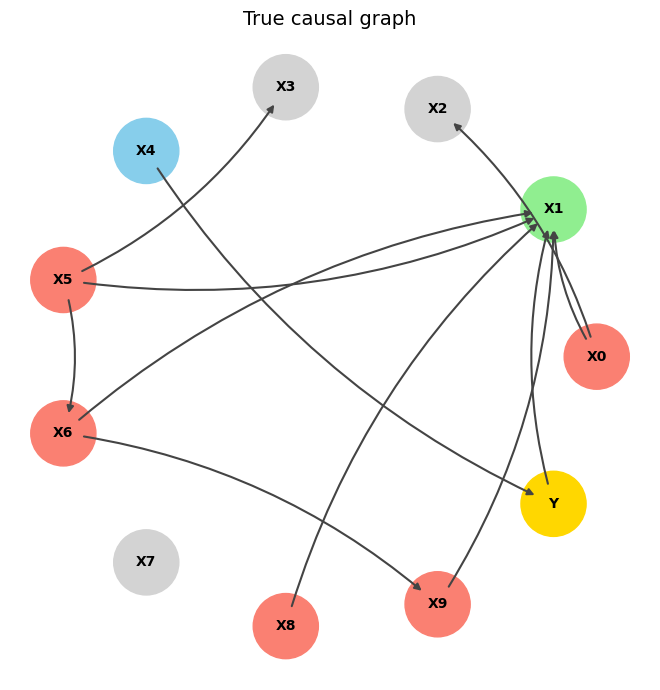

Number of variables: 11 (X0...X9 + Y)
True parents of Y: [4]
True children of Y: [1]
True spouses of Y: [5]


In [2]:
# Create an SCM with 10 variables + target Y
d = 10
scm = SCMGenerator(d=d)
scm.fit(n_parents=1, n_childs=1, n_spouses=1, sparsity=0.2, noise_type='uniform')

# Visualize the true graph
plot_graphs_from_adj([scm.A], Y_idx_list=[d], plot_titles=['True causal graph'])

print(f"Number of variables: {d + 1} (X0...X{d-1} + Y)")
print(f"True parents of Y: {scm.parents_idx}")
print(f"True children of Y: {scm.children_idx}")
print(f"True spouses of Y: {scm.spouses_idx}")


In [3]:
# Sample from the SCM
data = scm.sample(n_samples=10000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,0.194004,1.883044,-0.141706,0.035039,0.666322,0.197740,0.032471,0.321692,0.964543,0.150510,-1.006006
1,0.599281,-1.867911,0.526914,0.856349,-0.588413,0.701971,1.135221,0.371437,-0.812134,1.127060,0.797402
2,-0.825262,-0.416781,-0.511361,0.680111,0.461360,0.481501,0.464377,-0.648715,0.894778,0.859475,-0.137822
3,0.925724,1.877040,0.954501,0.440363,0.606828,0.712431,0.497776,-0.237073,0.536256,0.267554,-0.836502
4,0.297747,-0.399026,0.580159,0.052069,-0.913742,-0.007789,0.100876,-0.589675,0.797014,0.030713,1.379602


### 2.5 Run three algorithms and compare

We run PC (constraint-based), GES (score-based), and FCI (constraint-based, allows hidden variables) and compare their recovered graphs to the ground truth.


In [4]:
# PC Algorithm
start = time.time()
res_pc = pc_alg(data, alpha=0.05)
A_pc = adjacency(res_pc)
time_pc = time.time() - start
print(f"PC   : {time_pc:.2f}s")

# GES Algorithm
start = time.time()
res_ges = ges(data,     )
A_ges = adjacency(res_ges)
time_ges = time.time() - start
print(f"GES  : {time_ges:.2f}s")


PC   : 1.55s
GES  : 32.66s
FCI  : 1.48s


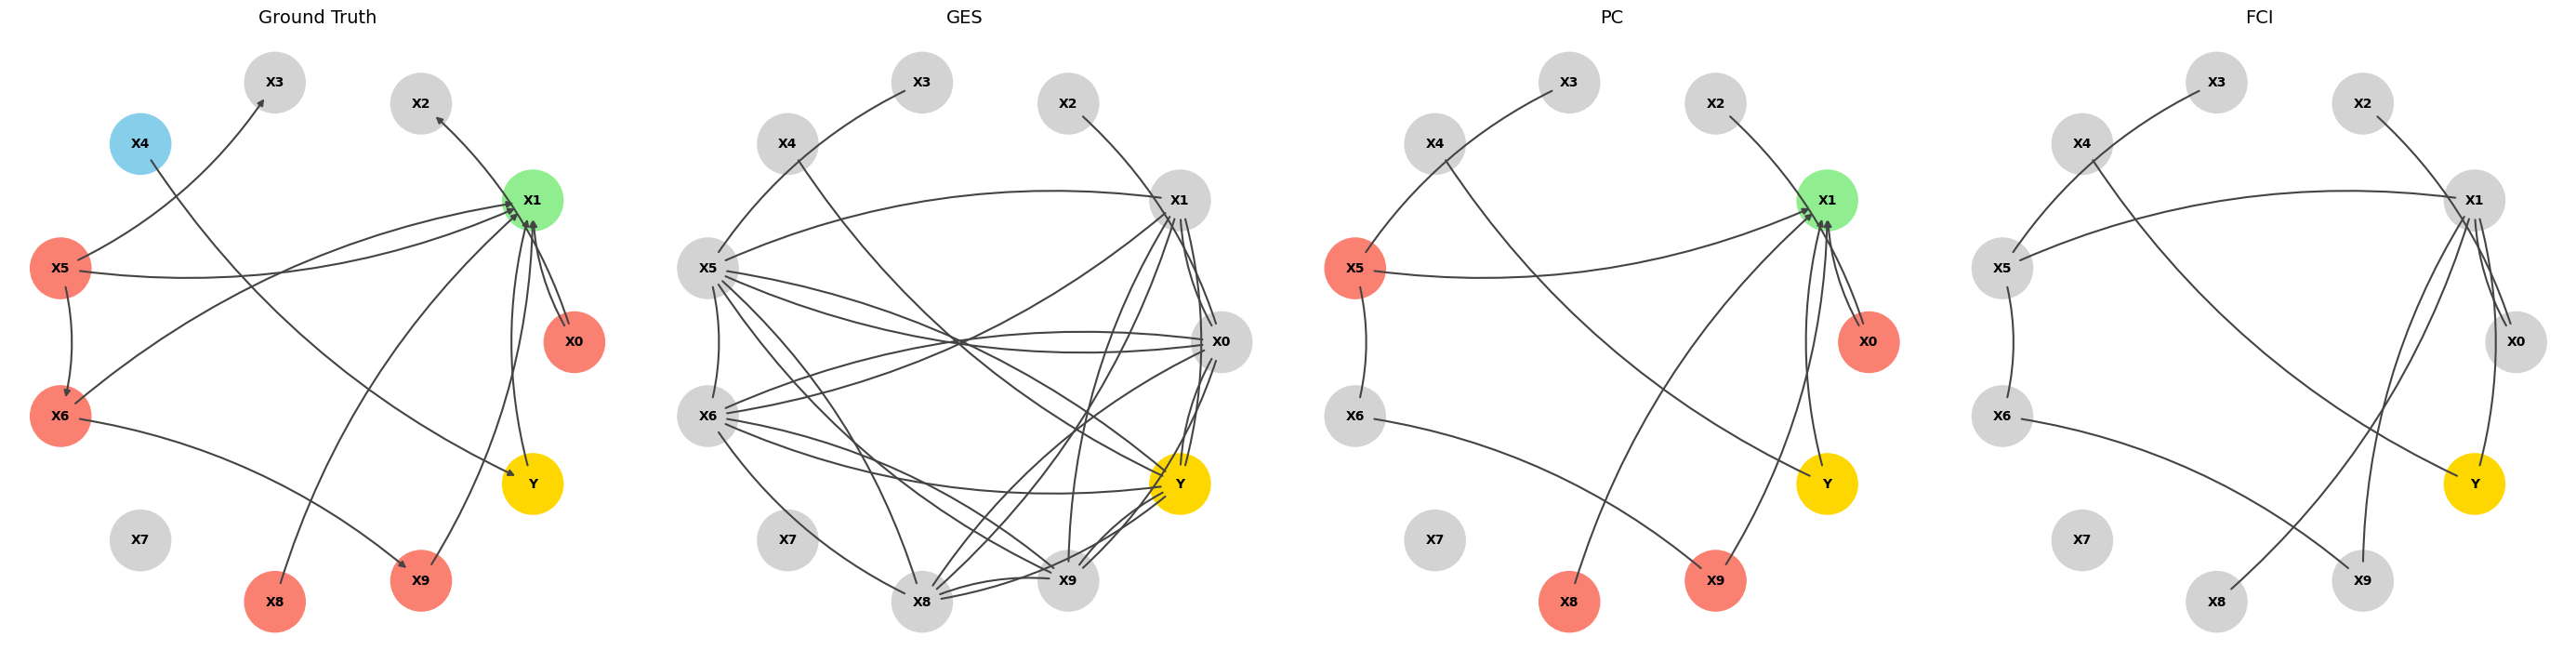

In [ ]:
# Compare recovered graphs to ground truth
plot_graphs_from_adj(
    [scm.A, A_ges.values, A_pc.values],
    Y_idx_list=[d, d, d],
    plot_titles=['Ground Truth', 'GES', 'PC']
)


### Questions — Multivariate causal discovery

**Q7.** The PC algorithm's complexity is often stated as O(p^q) where p is the number of variables and q is the maximum degree of the graph. What does this mean in practice for high-dimensional datasets?

**Q8.** GES operates in two phases: a forward phase (adding edges) and a backward phase (removing edges). Why is a single forward pass not sufficient?

**Q9.** FCI is slower than PC but has a key advantage. What is it, and when would you prefer FCI over PC?

**Q10.** You recovered a CPDAG instead of a DAG — some edges are undirected. What does this tell you about identifiability, and what additional information would you need to orient those edges?


**Answers:**

**A7.** The exponential dependence on q means that for dense graphs (high degree), the algorithm must run conditional independence tests conditioning on large sets of variables. Each such test requires enough samples to be reliable. For p=50 variables and maximum degree q=10, the number of tests grows dramatically. In practice, PC becomes computationally infeasible and statistically unreliable in dense high-dimensional settings. Sparse graph assumptions (like in genomics) make it tractable.

**A8.** The forward phase adds edges greedily to maximize score, but local greedy choices can create edges that turn out to be unnecessary once more of the graph is known. The backward phase corrects these by removing edges whose removal improves the score. Together, they perform a local search in the space of equivalence classes (ESSGs). A single forward pass would overfit the graph.

**A9.** FCI does not assume causal sufficiency — it can handle latent confounders. When there is a hidden variable H that causes both X_i and X_j, PC would falsely add an edge X_i—X_j. FCI uses o-marks and circle endpoints in its PAG representation to signal uncertainty about whether an edge is a direct cause or a confounded association. Use FCI when you suspect hidden common causes (which is almost always in observational biology or economics).

**A10.** An undirected edge in a CPDAG means both orientations are Markov equivalent — they encode the same set of conditional independencies. The observational distribution cannot distinguish them. To orient the edge, you would need: (a) an intervention on one of the variables, (b) additional temporal information, (c) functional assumptions (like non-Gaussian noise for LiNGAM), or (d) background knowledge.


### Exercise 2 — Effect of sample size

Re-run the three algorithms with `n_samples = 500` instead of 5000. How does graph recovery degrade? Which algorithm is most robust to small samples? Can you explain why?


In [6]:
# Your code here
# d = 10
# scm_small = SCMGenerator(d=d)
# scm_small.fit(n_parents=1, n_childs=1, n_spouses=1, sparsity=0.2, noise_type='uniform')
# data_small = scm_small.sample(n_samples=500)
# ...
